In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('downloads_study880_mapped_rpk.csv').set_index('peptide')
meta = pd.read_csv('../lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv').set_index('seq_id')

In [8]:
df_mAb = df.filter(regex='^Ab')

In [10]:
Ab_372D = df_mAb.filter(regex='Ab_37_2D')

Ab_2510C = df_mAb.filter(regex='Ab_25_10C')

Ab_377H = df_mAb.filter(regex='Ab_37_3H')

Ab_256A = df_mAb.filter(regex='Ab_25_6A')

Ab_129F = df_mAb.filter(regex='Ab_12_9F')

In [38]:
meta_lasv = meta.loc[meta['species'] == 'Mammarenavirus lassaense']

In [61]:
Ab_377H.mean(axis=1).sort_values(ascending=False).head(20)

peptide
AZI72696.1|polymerase|Kuka_mita_hah_virus_1|S17-252_3|Boa_constrictor|Switzerland|2017|L|?|tile_66                                                           17461.703290
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                                        17311.632641
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9                            11020.720028
XQH02907.1|polymerase|Sara_tick_phlebovirus|isolate=NM1YL/2021|Ixodes_persulcatus|China:_Hulunbeier-_Inner_Mongolia|2021|segment=L|strain=?|tile_55          10202.249668
YP_010085031.1|protein|Hainan_oriental_leaf-toed_gecko_hantavirus|isolate=?|Hemidactylus_bowringii|China|?|segment=L|strain=LPXYF84819|tile_75                5740.640612
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172                 

In [63]:
Ab_377H.loc[meta_lasv.index].mean(axis=1).sort_values(ascending=False).head(5)

seq_id
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                      17311.632641
AYD75256.1|protein|Mammarenavirus_lassaense|807987|Homo_sapiens|Liberia|1981|L|?|tile_44                                                    2495.110980
XBA96065.1|precursor|Mammarenavirus_lassaense|LF2350|Homo_sapiens|Sierra_Leone|2012|S|?|tile_17                                               19.702615
AYD75258.1|protein|Mammarenavirus_lassaense|807978|Homo_sapiens|Liberia|1981|L|?|tile_9                                                       17.396372
AZI95896.1|polymerase|Mammarenavirus_lassaense|LASV/H.sapiens-tc/NGA/2016/IRR_003|Homo_sapiens|Nigeria:_Plateau|04-Jan-2016|L|?|tile_33        9.550439
dtype: float64

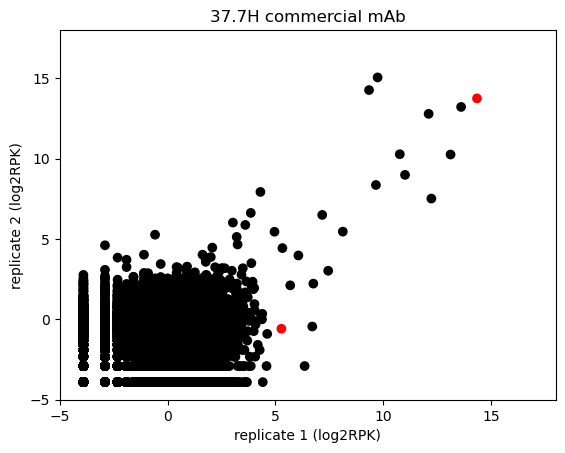

In [73]:
color_map = {'AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19': 'red', 
             'XBA96065.1|precursor|Mammarenavirus_lassaense|LF2350|Homo_sapiens|Sierra_Leone|2012|S|?|tile_17': 'red'}


colors = Ab_377H

x = Ab_377H.iloc[:, 0]
y = Ab_377H.iloc[:, 1]

x = np.log2(x)
y = np.log2(y)

colors = [color_map.get(peptide, 'black') for peptide in Ab_377H.index]


plt.scatter(x, y, color = colors, marker='o')

plt.xlabel('replicate 1 (log2RPK)')
plt.ylabel('replicate 2 (log2RPK)')

plt.title('37.7H commercial mAb')

plt.xlim(-5, 18)
plt.ylim(-5, 18) 

plt.savefig('37.7H_corr.svg', format='svg')
plt.show()

In [30]:
x.sort_values(ascending=False)

peptide
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                             14.347073
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9                 13.610216
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172                     13.121407
AYD75256.1|protein|Mammarenavirus_lassaense|807987|Homo_sapiens|Liberia|1981|L|?|tile_44                                                          12.230916
YP_010085031.1|protein|Hainan_oriental_leaf-toed_gecko_hantavirus|isolate=?|Hemidactylus_bowringii|China|?|segment=L|strain=LPXYF84819|tile_75    12.104242
                                                                                                                                                    ...    
YP_009507851.1|precursor|Hazara_virus|isolate=JC280|Ixod

In [31]:
peps = x.sort_values(ascending=False).head(5).index.to_list()

In [35]:
meta.loc[peps]

,sequence,accession,protein_name,gene,segment,order,family,subfamily,genus,species,isolate,taxonomy_lineage,collection_date,geo_loc_name,host,protein_std,fragment,collection_date_standardized
seq_id,,,,,,,,,,,,,,,,,,
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,AHC95553.1,glycoprotein precursor,NaN,S,Hareavirales,Arenaviridae,NaN,Mammarenavirus,Mammarenavirus lassaense,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,9-Jun,Mali,Mastomys natalensis,glycoprotein,19,2009-06
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9,VRSPAATTDDRLISDGLPNLRAMHAVDDLEAYSYRMPVPYHGFEYL,AMT75423.1,glycoprotein precursor,NaN,M,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus randallense,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Aug-69,"USA: Garza County, Texas",Argas sp.,glycoprotein,9,8/1/69
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172,VEDPRAYSEEQVTYLDLFEDGNTKDNNPAEEVKEPVGANYTFNWDD,QNS29866.1,RNA-dependent RNA polymerase,NaN,NaN,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus kasokeroense,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,13-Apr,Uganda,Ornithodoros faini,polymerase,172,2013-04
AYD75256.1|protein|Mammarenavirus_lassaense|807987|Homo_sapiens|Liberia|1981|L|?|tile_44,IYENSRLKERYFYCGHMSQCPIGELTKAVTTRTYFDHEYFQCFKSI,AYD75256.1,L protein,NaN,L,Hareavirales,Arenaviridae,NaN,Mammarenavirus,Mammarenavirus lassaense,807987,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,1981,Liberia,Homo sapiens,polymerase,44,1981
YP_010085031.1|protein|Hainan_oriental_leaf-toed_gecko_hantavirus|isolate=?|Hemidactylus_bowringii|China|?|segment=L|strain=LPXYF84819|tile_75,NLANRKAFSGKSYDAYCRQIYNPLTDQYEGDLRVTLNFGIDCAALE,YP_010085031.1,L protein,KM514_gp1,L,Elliovirales,Hantaviridae,Repantavirinae,Reptillovirus,Reptillovirus hemidactyli,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,China,Hemidactylus bowringii,polymerase,75,NaN


## now 25.6A

In [52]:
Ab_256A.mean(axis=1).sort_values(ascending=False).head(15)

peptide
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                                        70443.436951
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172                                11967.701204
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9                             6306.074658
YP_010839974.1|glycoprotein|Penshurt_virus|isolate=?|Choloepus_hoffmanni|Costa_Rica|2014|segment=M|strain=ANHV-Costa_Rica|tile_10                              665.659811
YP_010086221.1|glycoprotein|Karimabad_virus|isolate=91045-AG|Phlebotomus_papatasi|Iran|1975|segment=M|strain=?|tile_2                                          484.637780
YP_010839974.1|glycoprotein|Penshurt_virus|isolate=?|Choloepus_hoffmanni|Costa_Rica|2014|segment=M|strain=ANHV-Costa_Rica|tile_9              

In [55]:
meta.loc[Ab_256A.mean(axis=1).sort_values(ascending=False).head(5).index]['sequence']

peptide
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172        VEDPRAYSEEQVTYLDLFEDGNTKDNNPAEEVKEPVGANYTFNWDD
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9    VRSPAATTDDRLISDGLPNLRAMHAVDDLEAYSYRMPVPYHGFEYL
YP_010839974.1|glycoprotein|Penshurt_virus|isolate=?|Choloepus_hoffmanni|Costa_Rica|2014|segment=M|strain=ANHV-Costa_Rica|tile_10    QEKLDEAVDDLEDRKLERDRAISDHKRTLDEAAELRVEINHLHKLI
YP_010086221.1|glycoprotein|Karimabad_virus|isolate=91045-AG|Phlebotomus_papatasi|Iran|1975|segment=M|strain=?|tile_2                SKSGSTMDCFSSSTNAAFLAHFWDDAVGKLGDDVLSCKVNGVFSPI
Name: sequence, dtype: object

In [56]:
Ab_256A.loc[meta_lasv.index].mean(axis=1).sort_values(ascending=False).head(5)

seq_id
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                    70443.436951
XBA96065.1|precursor|Mammarenavirus_lassaense|LF2350|Homo_sapiens|Sierra_Leone|2012|S|?|tile_17                                             14.196545
AZI96412.1|precursor|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_064|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_17        4.910685
QNC69528.1|precursor|Mammarenavirus_lassaense|BEN-16090|Homo_sapiens|Benin|13-Mar-2016|S|?|tile_17                                           3.875368
AYD75258.1|protein|Mammarenavirus_lassaense|807978|Homo_sapiens|Liberia|1981|L|?|tile_9                                                      3.507405
dtype: float64

In [66]:
meta.loc['XBA96065.1|precursor|Mammarenavirus_lassaense|LF2350|Homo_sapiens|Sierra_Leone|2012|S|?|tile_17']['sequence']

'YWYLNHTTTGKTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEM'

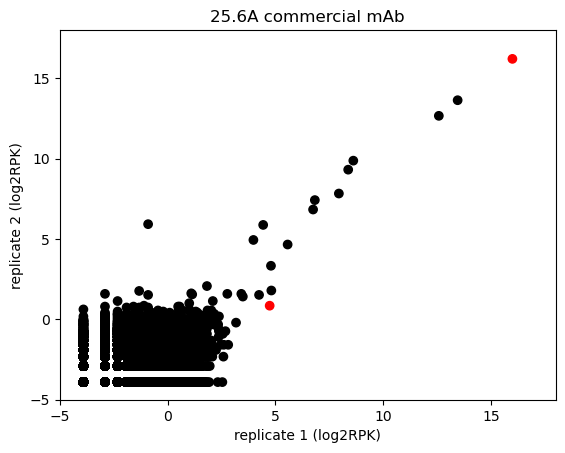

In [74]:
color_map = {'AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19': 'red', 
             'XBA96065.1|precursor|Mammarenavirus_lassaense|LF2350|Homo_sapiens|Sierra_Leone|2012|S|?|tile_17': 'red'}

colors = Ab_256A

x = Ab_256A.iloc[:, 0]
y = Ab_256A.iloc[:, 1]

x = np.log2(x)
y = np.log2(y)

colors = [color_map.get(peptide, 'black') for peptide in Ab_256A.index]


plt.scatter(x, y, color = colors, marker='o')

plt.xlabel('replicate 1 (log2RPK)')
plt.ylabel('replicate 2 (log2RPK)')

plt.xlim(-5, 18)
plt.ylim(-5, 18) 

plt.title('25.6A commercial mAb')

plt.savefig('25.6A_corr.svg', format='svg')

plt.show()

In [28]:
x.sort_values(ascending=False)

peptide
AHC95553.1|precursor|Mammarenavirus_lassaense|?|Mastomys_natalensis|Mali|Jun-2009|S|Soromba-R|tile_19                                15.988878
QNS29866.1|polymerase|Kasokero_virus|isolate=?|Ornithodoros_faini|Uganda|Apr-2013|segment=?|strain=UGA-Tick-20130533|tile_172        13.449407
AMT75423.1|precursor|Sapphire_II_virus|isolate=?|Argas_sp.|USA:_Garza_County-_Texas|Aug-1969|segment=M|strain=RML_52323-14|tile_9    12.577165
YP_010839974.1|glycoprotein|Penshurt_virus|isolate=?|Choloepus_hoffmanni|Costa_Rica|2014|segment=M|strain=ANHV-Costa_Rica|tile_10     8.611083
YP_010086221.1|glycoprotein|Karimabad_virus|isolate=91045-AG|Phlebotomus_papatasi|Iran|1975|segment=M|strain=?|tile_2                 8.374281
                                                                                                                                       ...    
YP_001649216.1|protein|Amapari_virus|?|?|Brazil|?|L|BeAn_70563|tile_7                                                                 